## GitHub Repository

This notebook is part of the **Machine Learning Labs** repository.

**GitHub Repository:**
https://github.com/ni766/Machine-Learning-Labs.git

**Repository:** `Machine-Learning-Labs`

**GitHub Username:** `ni766`


# ML Lab 3 — Decision Tree Classification

## Student Information

| Information | Details |
|---|---|
| **Name** | Nisha |
| **Student ID** | 023-24-0178 |
| **Section** | F |
| **GitHub Profile** | https://github.com/ni766 |
| **Kaggle Profile** | https://github.com/ni766/Machine-Learning-Labs.git |
| **Dataset** | Telco Customer Churn |
| **Dataset Source** | SAME SOURCE USED IN LAB 2 |

## **Task 1 — Load and Verify the Cleaned Dataset**

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("clean_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Task 2 — Restate the ML Problem**

# 1. Problem Definition

The goal of this machine learning task is to predict whether a telecom customer will churn (leave the company) based on the customer's demographic information, services, contract details, tenure, and billing information.

Predicting churn is important for the business because identifying customers who are likely to leave can help the company take preventive actions such as targeted offers, improved customer support, or retention campaigns.

# 2. Dataset Verification

Before training the model, the cleaned dataset from Lab 2 is loaded and checked for its dimensions, data types, target distribution, and missing values.

In [2]:
print("Dataset shape:", df.shape)

Dataset shape: (7021, 20)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  Monthl

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [5]:
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn value counts:
Churn
No     5164
Yes    1857
Name: count, dtype: int64

Churn percentages:
Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64


### Interpretation

The cleaned dataset contains 7,021 rows and 20 columns. There are no missing values remaining, confirming that the cleaned Lab 2 dataset is intact and ready for machine learning.

The target variable is imbalanced: approximately 73.55% of customers did not churn while 26.45% did churn. Therefore, accuracy alone may not provide a complete picture of model performance, and precision, recall, F1-score, and the confusion matrix should also be considered.

# 3. Feature/Target Preparation

The target variable is separated from the predictor variables. The Churn target is converted from Yes/No into 1/0. Categorical predictor variables are then converted into numerical variables using one-hot encoding.

## **Task 3 — Define X and y**

In [6]:
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

X shape: (7021, 19)
y shape: (7021,)

Target values:
Churn
0    5164
1    1857
Name: count, dtype: int64


## **Task 4 — Convert Categorical Columns**

In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\Hp\AppData\Local\Temp\ipykernel_32216\3655768486.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [8]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)
print("Shape after one-hot encoding:", X.shape)

Shape after one-hot encoding: (7021, 45)


### Why one-hot encoding?

One-hot encoding is appropriate because most of the categorical variables do not have a natural numerical order. For example, payment methods and internet service types are categories rather than values where one category is inherently greater than another. One-hot encoding represents each category numerically without incorrectly introducing an artificial ranking.

## **Task 5 — Confirm X Is Numeric and Has No Missing Values**

In [ ]:
print("Are all X columns numeric?")
print(X.dtypes.apply(lambda dtype: np.issubdtype(dtype, np.number)).all())
print("\nTotal missing values in X:")
print(X.isnull().sum().sum())
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

Are all X columns numeric?
True

Total missing values in X:
0

Non-numeric columns:
[]


### Interpretation

After one-hot encoding, all predictor variables are numeric and there are no missing values. Therefore, X is in a suitable format for training a scikit-learn Decision Tree classifier.

# 4. **Task 6 — Train/Test Split**

The data is split into 80% training data and 20% testing data. I use `stratify=y` because the target variable is imbalanced, with approximately 73.55% non-churners and 26.45% churners. Stratification keeps a similar proportion of churners and non-churners in both the training and testing sets, making the evaluation more representative.


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5616, 45)
X_test shape: (1405, 45)
y_train shape: (5616,)
y_test shape: (1405,)


## **Task 7 — Report the Shapes**

The training set contains 5,616 observations and the test set contains 1,405 observations. Each observation has 45 predictor variables after one-hot encoding.


### Why stratify=y?

The target variable is imbalanced, with substantially more non-churners than churners. Using stratify=y keeps a similar proportion of churners and non-churners in both the training and test sets, making the evaluation more representative.

# 5. **Task 8 — Baseline Decision Tree**

A baseline Decision Tree classifier is trained using the training data. The default settings are used, with only `random_state=42` fixed to make the results reproducible. Predictions are generated for both the training and test sets so that the model's performance can later be compared.


In [11]:
from sklearn.tree import DecisionTreeClassifier
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_train_pred_baseline = baseline_model.predict(X_train)
y_test_pred_baseline = baseline_model.predict(X_test)
print("Training predictions generated:", len(y_train_pred_baseline))
print("Test predictions generated:", len(y_test_pred_baseline))

Training predictions generated: 5616
Test predictions generated: 1405


## **Task 9 — Determine the Baseline Tree Depth**

In [12]:
print("Baseline tree depth:", baseline_model.get_depth())

Baseline tree depth: 24


### Interpretation

The unrestricted Decision Tree grew to a depth of 24. This is relatively deep and is not surprising because the default Decision Tree is allowed to continue splitting until stopping conditions are reached. The large depth suggests that the model may be complex and potentially prone to overfitting.

## **Task 10 — Baseline Model Evaluation**

The baseline Decision Tree is evaluated on the test set using accuracy, precision, recall, and F1-score. These four metrics provide a more complete evaluation than accuracy alone, especially because the Churn target variable is imbalanced.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_accuracy = accuracy_score(y_test, y_test_pred_baseline)
baseline_precision = precision_score(y_test, y_test_pred_baseline)
baseline_recall = recall_score(y_test, y_test_pred_baseline)
baseline_f1 = f1_score(y_test, y_test_pred_baseline)

baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

baseline_results

,Metric,Score
0,Accuracy,0.715302
1,Precision,0.464824
2,Recall,0.497312
3,F1-score,0.480519


### **Interpretation**

The baseline Decision Tree achieved approximately 71.53% accuracy on the test set. Its precision was approximately 46.48%, recall was 49.73%, and F1-score was 48.05%. These results show that accuracy alone does not fully describe the model's ability to identify customers who churn.


## **Task 11 — Confusion Matrix**

The confusion matrix shows how the baseline Decision Tree classified actual churners and non-churners. It helps identify both correctly classified customers and the customers that the model classified incorrectly.


Confusion Matrix:
[[820 213]
 [187 185]]


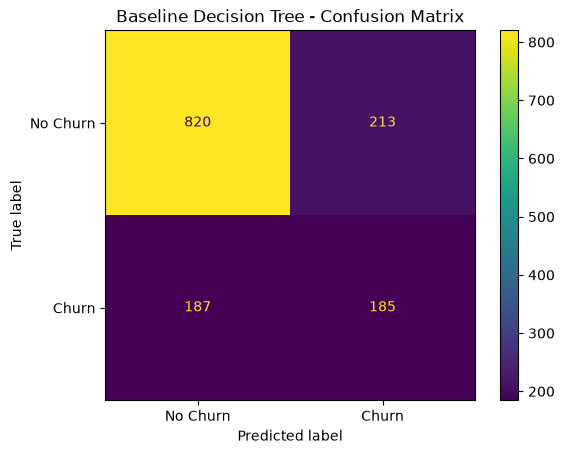

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_baseline = confusion_matrix(y_test, y_test_pred_baseline)
print("Confusion Matrix:")
print(cm_baseline)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

### **Interpretation**

The confusion matrix shows that there were 372 actual churners in the test set. The model correctly identified 185 churners, while it missed 187 actual churners. Therefore, the baseline model correctly caught approximately half of the customers who actually churned, showing that there is room for improvement in identifying churners.


## **Task 12 — Metric Selection**

Because the Churn target variable is imbalanced, accuracy alone is not the most reliable metric for this problem. I trust **recall and F1-score** more because recall measures how many actual churners the model successfully identifies, while F1-score balances precision and recall. Recall is especially important for the business because missing a customer who is likely to churn could mean losing an opportunity to take preventive retention action.


## **Task 13 — Compare Training and Test Accuracy**

The baseline Decision Tree achieved approximately 99.77% accuracy on the training set but only 71.53% accuracy on the test set. The large difference between training and test performance indicates that the unrestricted tree has overfit the training data and does not generalize as well to unseen data.


In [ ]:
from sklearn.metrics import accuracy_score
train_accuracy_baseline = accuracy_score(y_train, y_train_pred_baseline)
test_accuracy_baseline = accuracy_score(y_test, y_test_pred_baseline)
accuracy_gap = train_accuracy_baseline - test_accuracy_baseline
print("Training accuracy:", train_accuracy_baseline)
print("Test accuracy:", test_accuracy_baseline)
print("Accuracy gap:", accuracy_gap)

Training accuracy: 0.9976851851851852
Test accuracy: 0.7153024911032029
Accuracy gap: 0.28238269408198235


### **Interpretation**

The training accuracy is approximately 99.77%, while the test accuracy is approximately 71.53%, giving an accuracy gap of about 28.24 percentage points. This is a large gap and strongly suggests that the unrestricted Decision Tree is overfitting the training data.


## **Task 14 — Multiple Tree Depths**

Several Decision Trees are trained using different `max_depth` values: 2, 3, 4, 5, 6, 8, 10, and an unrestricted tree. Training and test accuracy are recorded for each model so that the effect of tree depth on model performance and overfitting can be compared.


In [ ]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []
for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        "max_depth": "Unrestricted" if depth is None else depth,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })
depth_results = pd.DataFrame(results)
depth_results

,max_depth,train_accuracy,test_accuracy
0,2,0.764245,0.755872
1,3,0.792557,0.786477
2,4,0.798433,0.786477
3,5,0.802172,0.794306
4,6,0.813925,0.793594
5,8,0.841346,0.780783
6,10,0.879274,0.775801
7,Unrestricted,0.997685,0.715302


### **Interpretation**

The results show that training accuracy generally increases as the maximum tree depth increases. Test accuracy improves from depth 2 through depth 5, reaching its highest value of approximately 79.43% at depth 5. After depth 5, test accuracy begins to decrease while training accuracy continues to increase, which indicates increasing overfitting as the tree becomes deeper.


## **Task 15 — Accuracy vs. Tree Depth**

The training and test accuracies are plotted against `max_depth` on the same chart. This allows us to visually identify where the model begins to overfit as the tree becomes more complex.


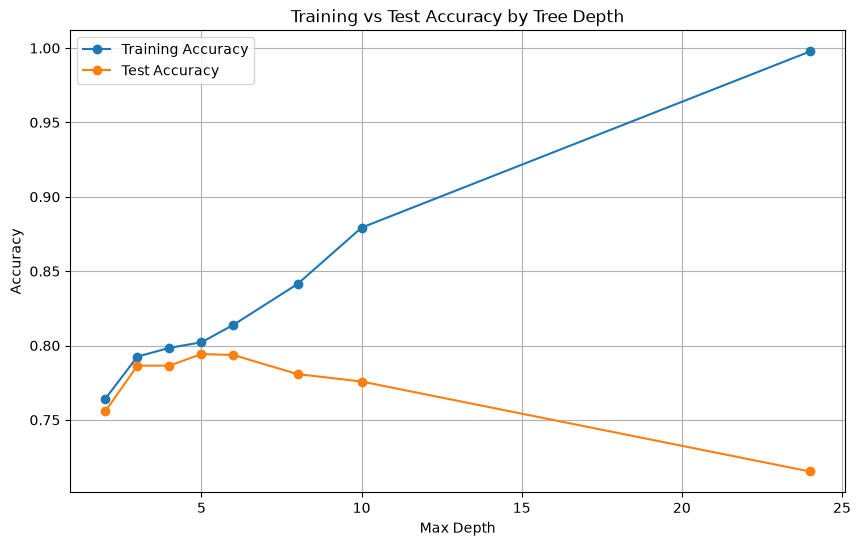

In [ ]:
plot_depths = [2, 3, 4, 5, 6, 8, 10, 24]
train_accuracy = depth_results["train_accuracy"]
test_accuracy = depth_results["test_accuracy"]
plt.figure(figsize=(10, 6))
plt.plot(
    plot_depths,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    plot_depths,
    test_accuracy,
    marker="o",
    label="Test Accuracy"
)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

### **Interpretation**

The chart shows that training accuracy increases as the tree becomes deeper, while test accuracy improves until approximately **depth 5**. After depth 5, test accuracy starts to decline while training accuracy continues to increase, creating a larger gap between the two. This indicates that the model starts showing signs of overfitting at approximately **depth 6 and beyond**, with the unrestricted tree showing the most severe overfitting.


# 8. Model Comparison

Based on the depth experiment, depth 5 provides a good balance between model complexity and generalization. It gives the highest test accuracy among the tested depths while keeping the training-test gap much smaller than the unrestricted tree.

## Task 16 - Select best depth

### Selected Model: max_depth = 5

I selected max_depth=5 because it achieved the highest test accuracy among the tested tree depths at approximately 79.43%. Although deeper trees achieved higher training accuracy, their test accuracy decreased, indicating overfitting. Therefore, depth 5 provides a better balance between training performance and generalization to unseen data.

## Task 17 - Retrain chosen model

In [ ]:
chosen_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
chosen_model.fit(X_train, y_train)
y_test_pred_chosen = chosen_model.predict(X_test)
chosen_accuracy = accuracy_score(y_test, y_test_pred_chosen)
chosen_precision = precision_score(y_test, y_test_pred_chosen)
chosen_recall = recall_score(y_test, y_test_pred_chosen)
chosen_f1 = f1_score(y_test, y_test_pred_chosen)
chosen_cm = confusion_matrix(y_test, y_test_pred_chosen)
chosen_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        chosen_accuracy,
        chosen_precision,
        chosen_recall,
        chosen_f1
    ]
})

chosen_results

,Metric,Score
0,Accuracy,0.794306
1,Precision,0.620290
2,Recall,0.575269
3,F1-score,0.596932


### Interpretation

The depth-5 Decision Tree achieved approximately 79.43% test accuracy, with 62.03% precision, 57.53% recall, and a 59.69% F1-score. It correctly identified 214 of the 372 actual churners and missed 158. Compared with the unrestricted baseline, the depth-5 model generalizes substantially better to unseen customers.

## Task 18 - Entropy criterion

In [ ]:
entropy_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="entropy",
    random_state=42
)
entropy_model.fit(X_train, y_train)
y_test_pred_entropy = entropy_model.predict(X_test)
entropy_accuracy = accuracy_score(y_test, y_test_pred_entropy)
entropy_precision = precision_score(y_test, y_test_pred_entropy)
entropy_recall = recall_score(y_test, y_test_pred_entropy)
entropy_f1 = f1_score(y_test, y_test_pred_entropy)
entropy_cm = confusion_matrix(y_test, y_test_pred_entropy)
entropy_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})
entropy_results

,Metric,Score
0,Accuracy,0.790747
1,Precision,0.601562
2,Recall,0.620968
3,F1-score,0.611111


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline - Gini, unrestricted",
        "Chosen - Gini, depth 5",
        "Entropy - depth 5"
    ],
    "Accuracy": [
        baseline_accuracy,
        chosen_accuracy,
        entropy_accuracy
    ],
    "Precision": [
        baseline_precision,
        chosen_precision,
        entropy_precision
    ],
    "Recall": [
        baseline_recall,
        chosen_recall,
        entropy_recall
    ],
    "F1-score": [
        baseline_f1,
        chosen_f1,
        entropy_f1
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,"Baseline - Gini, unrestricted",0.715302,0.464824,0.497312,0.480519
1,"Chosen - Gini, depth 5",0.794306,0.620290,0.575269,0.596932
2,Entropy - depth 5,0.790747,0.601562,0.620968,0.611111


### Interpretation

The depth-5 Gini model has the highest accuracy and precision, while the depth-5 entropy model has the highest recall and F1-score. Since identifying churners is important and the dataset is imbalanced, the entropy model is particularly attractive because it catches more actual churners and achieves the highest F1-score. However, the depth-5 Gini model has slightly better overall accuracy and precision.

# 9. Feature Importance

Feature importance is extracted from the selected depth-5 Decision Tree. The importance values indicate how much each feature contributes to the tree's decisions.

## Task 19 - Extract importance

In [ ]:
feature_importance = pd.Series(
    chosen_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print("Top 10 features:")
print(feature_importance.head(10))

Top 10 features:
Contract_Month-to-month           0.509102
tenure                            0.168379
InternetService_Fiber optic       0.157871
TotalCharges                      0.037767
MonthlyCharges                    0.032543
OnlineSecurity_No                 0.023097
MultipleLines_No phone service    0.015068
MultipleLines_No                  0.013831
PaymentMethod_Electronic check    0.013776
OnlineBackup_No                   0.006235
dtype: float64


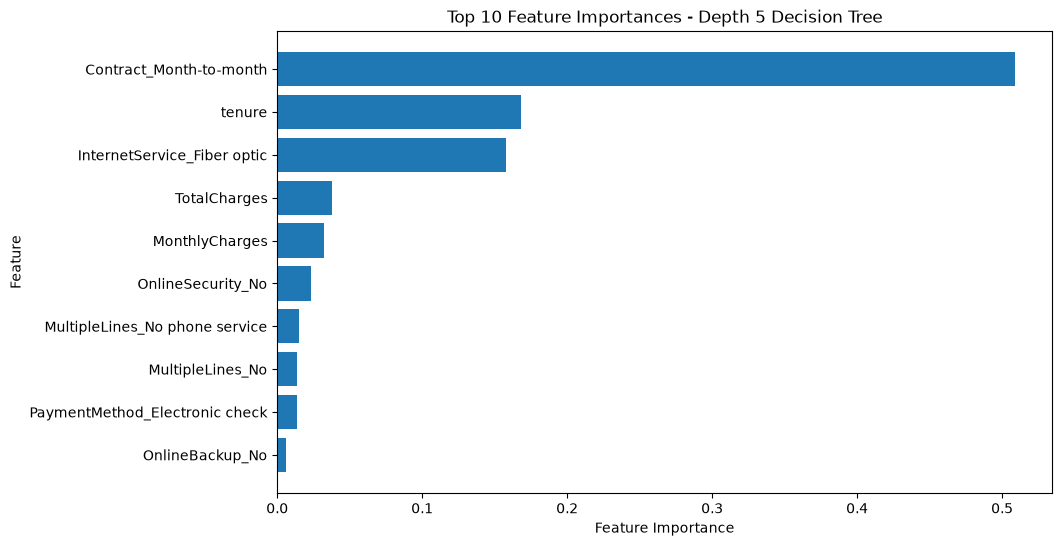

In [ ]:
top_features = feature_importance.head(10).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(
    top_features.index,
    top_features.values
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Depth 5 Decision Tree")
plt.show()

### Interpretation

The feature-importance plot shows that Contract_Month-to-month is by far the most important feature, followed by tenure and InternetService_Fiber optic. TotalCharges and MonthlyCharges have smaller but still noticeable contributions. This indicates that contract type, customer tenure, and internet service type are important factors in the tree's churn predictions.

## Task 20 - Connect with the lab 2 EDA

# 10. Interpretation

The feature importance results agree strongly with the patterns identified during the Lab 2 EDA. Month-to-month contract customers were previously found to have substantially higher churn than customers with one-year or two-year contracts, and contract type is also the most important feature in the Decision Tree. Tenure and internet service type are also important, which is consistent with the EDA finding that customer length of relationship and service characteristics are associated with churn.

# 11. Task 21 - Conclusion

The main model developed in this lab was a Decision Tree classifier for predicting customer churn. The unrestricted baseline tree reached approximately 99.77% training accuracy but only 71.53% test accuracy, demonstrating substantial overfitting. Limiting the tree to max_depth=5 improved test accuracy to approximately 79.43% and produced a much smaller training-test performance gap. The entropy-based depth-5 model achieved the highest F1-score of approximately 61.11% and the highest recall of approximately 62.10%, making it useful when identifying as many potential churners as possible is important. The main limitations are the class imbalance, moderate recall, and the fact that a single Decision Tree may not generalize as well as more advanced ensemble methods.

## Task 22 - What would you try next?

## Next Steps

If more time were available, I would first investigate additional feature engineering and methods for handling the class imbalance, such as class weighting or resampling. I would also compare the Decision Tree with other algorithms such as Logistic Regression, Random Forest, or Gradient Boosting in a future lab. Additional hyperparameter tuning could also be explored after establishing a reliable baseline. These methods may improve the model's ability to identify churners while maintaining good generalization.

# 12. Task 23 - ID3 From Scratch — Play Badminton

For this section, the ID3 decision tree algorithm is implemented from scratch using the Play Badminton dataset. No built-in decision tree library is used. The implementation calculates entropy and information gain manually and prints the information gain for every attribute considered at each split.

In [23]:
import pandas as pd
play_data = pd.DataFrame({
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain",
        "Rain", "Overcast", "Sunny", "Sunny", "Rain",
        "Sunny", "Overcast", "Overcast", "Rain"
    ],
    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool",
        "Cool", "Cool", "Mild", "Cool", "Mild",
        "Mild", "Mild", "Hot", "Mild"
    ],
    "Humidity": [
        "High", "High", "High", "High", "Normal",
        "Normal", "Normal", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "High"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Strong"
    ],
    "Play": [
        "No", "No", "Yes", "Yes", "Yes",
        "No", "Yes", "No", "Yes", "Yes",
        "Yes", "Yes", "Yes", "No"
    ]
})

play_data

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
import math
def entropy(data, target_column):
    
    
    values = data[target_column].value_counts()
    total = len(data)
    
    ent = 0
    
    for count in values:
        probability = count / total
        
        if probability > 0:
            ent -= probability * math.log2(probability)
    
    return ent

In [ ]:
def information_gain(data, attribute, target_column):

    total_entropy = entropy(data, target_column)
    
    weighted_entropy = 0
    
    for value in data[attribute].unique():
        
        subset = data[data[attribute] == value]
        
        subset_entropy = entropy(subset, target_column)
        
        weight = len(subset) / len(data)
        
        weighted_entropy += weight * subset_entropy
    
    gain = total_entropy - weighted_entropy
    
    return gain

In [26]:
attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

target = "Play"

print("Information Gain at Root:")
print("-" * 40)

for attribute in attributes:
    gain = information_gain(
        play_data,
        attribute,
        target
    )
    
    print(f"{attribute}: {gain:.4f}")

Information Gain at Root:
----------------------------------------
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481


In [27]:
def id3(data, attributes, target_column, depth=0):
    indent = "    " * depth
    if len(data[target_column].unique()) == 1:
        result = data[target_column].iloc[0]
        print(indent + "Leaf:", result)
        return result
    if len(attributes) == 0:
        result = data[target_column].mode()[0]
        print(indent + "Leaf:", result)
        return result
    print("\n" + indent + "Current dataset size:", len(data))
    
    print(indent + "Information Gain:")
    
    gains = {}
    
    for attribute in attributes:
        gain = information_gain(
            data,
            attribute,
            target_column
        )
        
        gains[attribute] = gain
        
        print(
            indent +
            f"  {attribute}: {gain:.4f}"
        )
    best_attribute = max(
        gains,
        key=gains.get
    )
    
    print(
        indent +
        f"Best attribute: {best_attribute}"
    )
    
    tree = {
        best_attribute: {}
    }
    
    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best_attribute
    ]
    for value in data[best_attribute].unique():
        
        print(
            indent +
            f"\nBranch: {best_attribute} = {value}"
        )
        
        subset = data[
            data[best_attribute] == value
        ]
        if len(subset) == 0:
            result = data[target_column].mode()[0]
            tree[best_attribute][value] = result
            
        else:
            tree[best_attribute][value] = id3(
                subset,
                remaining_attributes,
                target_column,
                depth + 1
            )
    
    return tree

In [29]:
attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]
print(" ID3 DECISION TREE ")
id3_tree = id3(
    play_data,
    attributes,
    "Play"
)

print("\n FINAL TREE ")
print(id3_tree)

 ID3 DECISION TREE 

Current dataset size: 14
Information Gain:
  Outlook: 0.2467
  Temperature: 0.0292
  Humidity: 0.1518
  Wind: 0.0481
Best attribute: Outlook

Branch: Outlook = Sunny

    Current dataset size: 5
    Information Gain:
      Temperature: 0.5710
      Humidity: 0.9710
      Wind: 0.0200
    Best attribute: Humidity
    
Branch: Humidity = High
        Leaf: No
    
Branch: Humidity = Normal
        Leaf: Yes

Branch: Outlook = Overcast
    Leaf: Yes

Branch: Outlook = Rain

    Current dataset size: 5
    Information Gain:
      Temperature: 0.0200
      Humidity: 0.0200
      Wind: 0.9710
    Best attribute: Wind
    
Branch: Wind = Weak
        Leaf: Yes
    
Branch: Wind = Strong
        Leaf: No

 FINAL TREE 
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


In [30]:
root_entropy = entropy(
    play_data,
    "Play"
)

print("Root Entropy:", round(root_entropy, 4))

Root Entropy: 0.9403


### ID3 Interpretation

The ID3 algorithm first calculates the entropy of the complete Play Badminton dataset and then calculates information gain for every available attribute. Outlook has the highest information gain at the root, so it is selected as the first splitting attribute. The same process is then repeated recursively for each branch using the remaining attributes. This demonstrates how ID3 selects attributes based on information gain without relying on a built-in decision tree library.

# Part 1 — Decision Tree Baseline Review

Before improving the model, the Lab 3 Decision Tree is re-established as the benchmark. The same cleaned dataset, feature preparation, train/test split, and random state are used so that later models can be compared fairly with this baseline.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Task 1 — Re-load the Cleaned Lab 2 Dataset

The cleaned dataset from Lab 2 is loaded again. The target variable `Churn` is separated from the input features, and the `customerID` column is removed.


In [2]:
df = pd.read_csv("clean_churn.csv")

y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7021, 19)
y shape: (7021,)


## Feature Encoding

Categorical features are converted into numerical features using one-hot encoding.


In [3]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("X shape after one-hot encoding:", X.shape)

X shape after one-hot encoding: (7021, 45)


C:\Users\Hp\AppData\Local\Temp\ipykernel_8488\1581951459.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


## Train/Test Split

The same 80/20 train/test split used in Lab 3 is recreated using `random_state=42` and `stratify=y`.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5616, 45)
X_test shape: (1405, 45)
y_train shape: (5616,)
y_test shape: (1405,)


## Task 2 — Retrain the Lab 3 Best Decision Tree

The best Decision Tree from Lab 3 used `max_depth=5`. The same model is retrained to establish the benchmark for the rest of the lab.


In [5]:
benchmark_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

benchmark_model.fit(X_train, y_train)

y_test_pred = benchmark_model.predict(X_test)

print("Benchmark Decision Tree trained successfully.")

Benchmark Decision Tree trained successfully.


## Test-Set Evaluation

The benchmark model is evaluated using accuracy, precision, recall, and F1-score.


In [6]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.7943
Precision: 0.6203
Recall: 0.5753
F1-score: 0.5969


## Benchmark Results

The following table shows the test-set performance of the Lab 3 Decision Tree benchmark.


In [7]:
benchmark_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

benchmark_results

,Metric,Score
0,Accuracy,0.794306
1,Precision,0.620290
2,Recall,0.575269
3,F1-score,0.596932


## Interpretation

The Lab 3 Decision Tree with `max_depth=5` is used as the benchmark model. In Lab 3, it achieved approximately 79.43% accuracy, 62.03% precision, 57.53% recall, and 59.69% F1-score on the test set.

These results will be used as the reference point for comparing the improved models in the remaining parts of the lab.


# Part 2 — Random Forest

A Random Forest combines multiple Decision Trees instead of relying on a single tree. Each tree is trained using different bootstrapped samples, and their predictions are combined to produce the final prediction.


## Task 3 — Train a Random Forest

A Random Forest with 200 trees is trained using the same training data as the Decision Tree benchmark. The `random_state` is fixed at 42 to make the results reproducible.


In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_test_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Generate Test Predictions

The trained Random Forest is used to generate predictions for the test dataset.


In [10]:
print("Number of test predictions:", len(y_test_pred_rf))
print("First 10 predictions:", y_test_pred_rf[:10])

Number of test predictions: 1405
First 10 predictions: [1 1 1 0 0 0 0 1 0 0]


## Task 4 — Why Random Forest May Generalize Better

A Random Forest can generalize better because it combines predictions from many different Decision Trees instead of depending on one tree. This reduces the effect of overfitting and makes the final model more stable on unseen data.


### Task 5 — Random Forest Evaluation

The Random Forest model is evaluated on the test set using accuracy, precision, recall, and F1-score. A confusion matrix is also plotted to visualize correct and incorrect predictions for the No Churn and Churn classes.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


y_pred_rf = rf_model.predict(X_test)


rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)


print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)


print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Evaluation
------------------------
Accuracy : 0.7722419928825622
Precision: 0.5921985815602837
Recall   : 0.4489247311827957
F1-score : 0.5107033639143731

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.59      0.45      0.51       372

    accuracy                           0.77      1405
   macro avg       0.70      0.67      0.68      1405
weighted avg       0.76      0.77      0.76      1405



### Random Forest Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the Random Forest model.

For the churn prediction problem:

* **True Negative (TN):** Correctly predicted No Churn.
* **False Positive (FP):** Predicted Churn when the customer did not churn.
* **False Negative (FN):** Predicted No Churn when the customer actually churned.
* **True Positive (TP):** Correctly predicted Churn.

The confusion matrix helps us understand how well the model identifies each class.


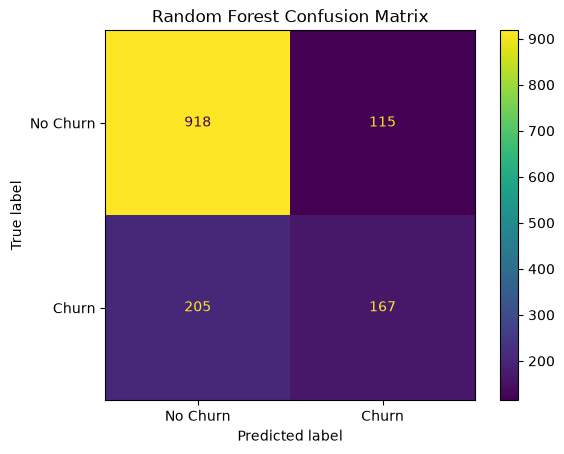

In [ ]:

cm_rf = confusion_matrix(y_test, y_pred_rf)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Task: 6 Decision Tree vs Random Forest

The Decision Tree and Random Forest models are compared using accuracy, precision, recall, and F1-score.

Using the same evaluation metrics for both models allows us to determine how their performance differs on the test set.


In [ ]:

dt_accuracy = accuracy_score(y_test, y_test_pred)
dt_precision = precision_score(y_test, y_test_pred)
dt_recall = recall_score(y_test, y_test_pred)
dt_f1 = f1_score(y_test, y_test_pred)

print("Decision Tree Evaluation")
print("-----------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Decision Tree Evaluation
-----------------------
Accuracy : 0.7943060498220641
Precision: 0.6202898550724638
Recall   : 0.5752688172043011
F1-score : 0.596931659693166


In [19]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.794306,0.772242
1,Precision,0.620290,0.592199
2,Recall,0.575269,0.448925
3,F1-score,0.596932,0.510703


### Task 7 — Which Model Performs Better?

The Decision Tree and Random Forest models are compared using accuracy, precision, recall, and F1-score.

Because the Telco Churn dataset has class imbalance, accuracy alone is not sufficient for evaluating model performance. Recall for the Churn class is particularly important because it measures how many of the actual churn customers are correctly identified. F1-score is also useful because it balances precision and recall.

Based on the comparison table, the differences between the Decision Tree and Random Forest are evaluated across all four metrics.


### Task 8 — 5-Fold Cross-Validation

A single train/test split can give a noisy estimate of model performance because the result depends on which observations happen to be placed in the training and test sets.

To obtain a more reliable estimate, 5-fold cross-validation is performed for both the Decision Tree and Random Forest models.

F1-score is used instead of plain accuracy because the Telco Churn dataset has class imbalance. Cross-validation produces five F1-scores for each model. The mean represents the average performance, while the standard deviation shows how much the performance varies across the five folds.


In [ ]:
from sklearn.model_selection import cross_val_score
dt_cv_scores = cross_val_score(
    benchmark_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree F1 Scores:")
print(dt_cv_scores)

print("\nRandom Forest F1 Scores:")
print(rf_cv_scores)
print("\nDecision Tree:")
print("Mean F1-score:", dt_cv_scores.mean())
print("Standard Deviation:", dt_cv_scores.std())

print("\nRandom Forest:")
print("Mean F1-score:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Decision Tree F1 Scores:
[0.6122449  0.62078273 0.59602649 0.5884058  0.57267442]

Random Forest F1 Scores:
[0.55727554 0.54324734 0.50374813 0.5400314  0.55950541]

Decision Tree:
Mean F1-score: 0.5980268659554786
Standard Deviation: 0.017083879294710787

Random Forest:
Mean F1-score: 0.5407615637901891
Standard Deviation: 0.02000374992445104


In [21]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Mean F1-score": [
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Standard Deviation": [
        dt_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_comparison

,Model,Mean F1-score,Standard Deviation
0,Decision Tree,0.598027,0.017084
1,Random Forest,0.540762,0.020004


### Task 9 — Cross-Validation vs Single Train/Test Split

In Part 3, the models were evaluated using a single train/test split. The Decision Tree achieved an F1-score of approximately 0.597 on the test set.

The 5-fold cross-validation results provide five different F1-scores for each model and summarize them using the mean and standard deviation.

The cross-validation results can be compared with the single test-set results to determine whether the model performance is consistent across different data splits.

If the cross-validation mean is close to the Part 3 test-set F1-score, the single-split result appears reasonably consistent with the cross-validated estimate. A larger difference suggests that the single train/test split may not fully represent the model's typical performance.

The standard deviation also provides information about the stability of the model across different folds. A smaller standard deviation indicates less variation between folds.

The comparison between the Decision Tree and Random Forest should therefore consider both their mean F1-scores and their standard deviations rather than relying on one train/test split alone.


### Task 9 — Interpretation

In Part 3, the Decision Tree achieved an F1-score of **0.5969** on the single test set. In 5-fold cross-validation, the Decision Tree achieved a mean F1-score of **0.5980**.

These two values are very close, showing that the Decision Tree's performance on the single test split was consistent with its average performance across the five cross-validation folds.

The Random Forest achieved a mean F1-score of **0.5408** in 5-fold cross-validation. Its cross-validated performance should be compared with its single train/test F1-score from Part 3 to determine whether the original test-set result was representative.

Overall, cross-validation provides more confidence in the performance estimate because it evaluates the models on multiple different data splits rather than relying on only one train/test split.

For this dataset and F1-score metric, the cross-validation results show that the Decision Tree has a higher average F1-score than the Random Forest. The standard deviations are relatively small, indicating that the results do not vary dramatically across the five folds.


### Task 10 — Random Forest Hyperparameter Tuning

For this task, we tune three Random Forest hyperparameters:

* `n_estimators`: number of trees in the forest.
* `max_depth`: maximum depth of each decision tree.
* `min_samples_split`: minimum number of samples required to split an internal node.

A small grid is used to keep the search manageable. `GridSearchCV` tests every combination using 5-fold cross-validation. The F1-score is used as the scoring metric because the dataset contains class imbalance and F1 considers both precision and recall.


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}
rf_tuning_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X, y)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validated F1-score:
0.575922970904396


### Task 11 — Best Hyperparameters and Cross-Validated Score

The best hyperparameter combination is selected according to the highest mean F1-score obtained during 5-fold cross-validation.

The `best_params_` attribute gives the hyperparameter combination that performed best, while `best_score_` gives its corresponding mean cross-validated F1-score.


In [23]:
print("Best Hyperparameters:")
for parameter, value in grid_search.best_params_.items():
    print(parameter, "=", value)

print("\nBest Cross-Validated F1-score:")
print(grid_search.best_score_)

Best Hyperparameters:
max_depth = 10
min_samples_split = 5
n_estimators = 200

Best Cross-Validated F1-score:
0.575922970904396


### Task 12 — Evaluate the Tuned Random Forest

The best Random Forest model selected by GridSearchCV is evaluated on the held-out test set.

The same four metrics used earlier are reported:

* Accuracy
* Precision
* Recall
* F1-score

This allows the tuned Random Forest to be compared fairly with the default Random Forest and Decision Tree models from Part 3.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
tuned_rf_model = grid_search.best_estimator_
y_test_pred_tuned = tuned_rf_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_test_pred_tuned)
tuned_precision = precision_score(y_test, y_test_pred_tuned)
tuned_recall = recall_score(y_test, y_test_pred_tuned)
tuned_f1 = f1_score(y_test, y_test_pred_tuned)
print("Tuned Random Forest Evaluation")
print("------------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

Tuned Random Forest Evaluation
------------------------------
Accuracy : 0.8555160142348754
Precision: 0.782608695652174
Recall   : 0.6290322580645161
F1-score : 0.6974664679582713


## Part 6 — Final Comparison & Feature Importance

### Task 13 — Final Model Comparison

Compare the Decision Tree, default Random Forest, and tuned Random Forest using accuracy, precision, recall, and F1-score.

In [27]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        accuracy_score(y_test, y_test_pred_tuned)
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        precision_score(y_test, y_test_pred_tuned)
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        recall_score(y_test, y_test_pred_tuned)
    ],
    "F1-Score": [
        dt_f1,
        rf_f1,
        f1_score(y_test, y_test_pred_tuned)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.794306,0.620290,0.575269,0.596932
1,Random Forest,0.772242,0.592199,0.448925,0.510703
2,Tuned Random Forest,0.855516,0.782609,0.629032,0.697466


### Task 14 — Final Model Selection

The final model is selected based on its test-set performance across accuracy, precision, recall, and F1-score. F1-score is especially useful because it provides a balance between precision and recall rather than relying on accuracy alone.

In [28]:
comparison.sort_values("F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
2,Tuned Random Forest,0.855516,0.782609,0.629032,0.697466
0,Decision Tree,0.794306,0.620290,0.575269,0.596932
1,Random Forest,0.772242,0.592199,0.448925,0.510703


### Task 14 — Final Model Selection

The Tuned Random Forest is selected as the final model because it achieved the highest accuracy (0.856), precision (0.783), recall (0.629), and F1-score (0.697) among the three models. Its higher F1-score shows a better balance between precision and recall on the test set compared with the Decision Tree and default Random Forest.

### Task 15 — Feature Importance

Feature importance shows the relative importance assigned to each feature by the final Random Forest model.

In [29]:
final_model = tuned_rf_model
importances = final_model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importance

tenure                                     0.144508
TotalCharges                               0.126399
Contract_Month-to-month                    0.098797
MonthlyCharges                             0.084519
OnlineSecurity_No                          0.056676
InternetService_Fiber optic                0.054613
TechSupport_No                             0.044531
PaymentMethod_Electronic check             0.038980
Contract_Two year                          0.031495
InternetService_DSL                        0.018093
OnlineBackup_No                            0.017829
Contract_One year                          0.017326
DeviceProtection_No                        0.015019
OnlineSecurity_Yes                         0.014479
PaperlessBilling_Yes                       0.013115
TechSupport_Yes                            0.012744
PaperlessBilling_No                        0.012313
SeniorCitizen                              0.011714
StreamingMovies_No internet service        0.009378
Partner_Yes 

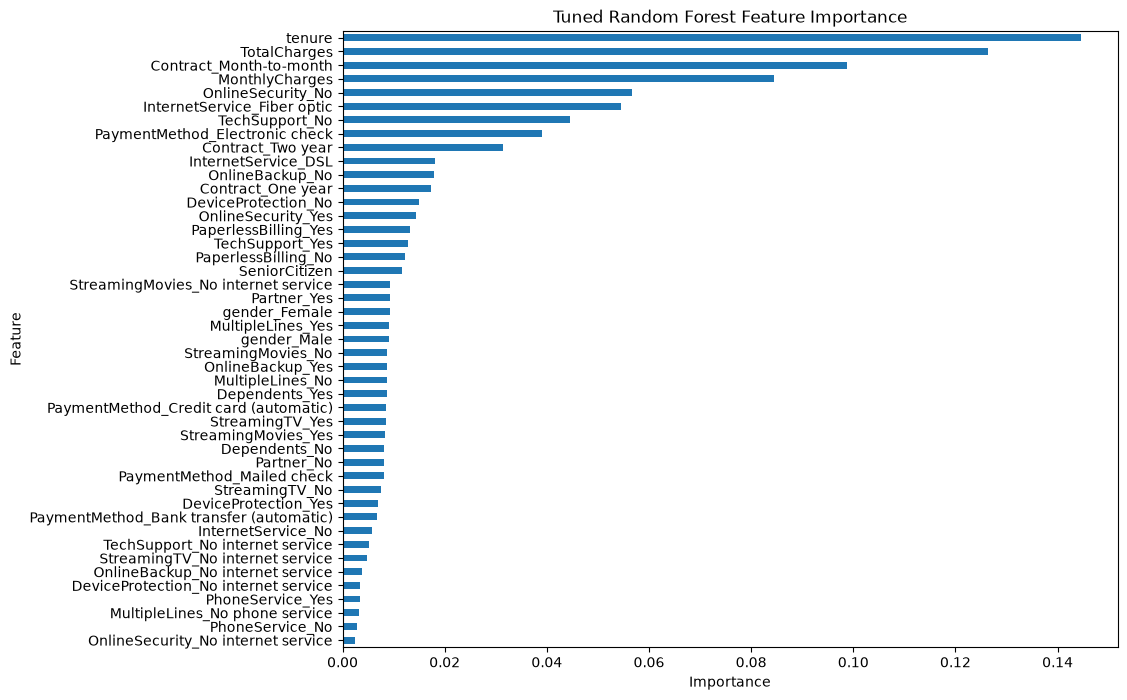

In [30]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot.barh(figsize=(10, 8))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.show()

In [31]:
feature_importance.head(5)

tenure                     0.144508
TotalCharges               0.126399
Contract_Month-to-month    0.098797
MonthlyCharges             0.084519
OnlineSecurity_No          0.056676
dtype: float64

### Task: 15 Feature Importance Interpretation

The Tuned Random Forest identified tenure as the most important feature, followed by TotalCharges, Contract_Month-to-month, MonthlyCharges, and OnlineSecurity_No. This suggests that customer length of service, total amount charged, contract type, monthly charges, and online security status contributed most to the model's churn predictions.

These results are broadly consistent with the findings from Lab 2 EDA and the Decision Tree, where contract type, tenure, and monthly charges showed noticeable relationships with churn. Therefore, the final Random Forest learned several patterns that were also observed in the earlier analysis.

## Task 16 — Kaggle Submission

Generate predictions using the final Tuned Random Forest model and create a submission-style dataframe containing the customer identifier and predicted Churn.

In [43]:
import pandas as pd

final_predictions = tuned_rf_model.predict(X_test)

submission = pd.DataFrame({
    "customerID": X_test.index,
    "Churn": final_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,customerID,Churn
0,5615,1
1,6112,1
2,2356,1
3,2196,0
4,832,0


In [44]:
submission.shape

(1405, 2)

In [45]:
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully


### Task 17 — Conclusion

The Tuned Random Forest was selected as the final model because it achieved the strongest test-set performance, with an accuracy of 0.856, precision of 0.783, recall of 0.629, and F1-score of 0.697. Compared with the Lab 3 Decision Tree, the Tuned Random Forest improved accuracy from 0.794 to 0.856 and F1-score from 0.597 to 0.697. The feature importance analysis showed that tenure, TotalCharges, contract type, MonthlyCharges, and OnlineSecurity were among the most important features. However, the model still has limitations, including imperfect recall, meaning some customers who churn may still be missed. Its performance may also depend on the dataset, preprocessing choices, and selected hyperparameters.

### Task 18 — Future Improvements

If I had more time, I would try additional algorithms such as Gradient Boosting, XGBoost, or Logistic Regression and compare their performance with the Random Forest. I would also explore more extensive hyperparameter tuning using cross-validation. Since churn prediction can involve class imbalance, I would test techniques such as class weights or resampling methods. I would also investigate additional feature engineering and evaluate whether removing low-importance features improves generalization.